In [1]:
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def chromadb_analysis(db, title = ''):
    results = db.get(include = ['metadatas','documents'])

    tickers = []
    length = []

    for doc,meta in zip(results['documents'],results['metadatas']):
        length.append(len(doc))
        tickers.append(meta['ticker'])

    df = pd.DataFrame({'ticker':tickers, 'length':length})

    plt.hist(df['length'], bins=40, range = (0,2500), weights=np.ones(len(df)) / len(df))
    plt.title('Character Length of Document for {}'.format(title))
    plt.xlabel('Number of Characters')
    plt.ylabel('Percentage')
    plt.show()

    plt.hist(df['ticker'].value_counts(), bins=20, range = (0,4000), weights=np.ones(len(df['ticker'].value_counts())) / len(df['ticker'].value_counts()))
    plt.title('Number of Documents Per Filling for {}'.format(title))
    plt.xlabel('Number of Documents')
    plt.ylabel('Percentage')
    plt.show()

    print(f"max length of all documents {df['length'].max()}")
    print(f"min length of all documents {df['length'].min()}")
    print(f"Percentage of documents with over 1000 words {sum(df['length'] >= 1000)/len(df)}")
    print(f"Percentage of documents with over 1500 words {sum(df['length'] >= 1500)/len(df)}")
    print(f"Percentage of documents with over 2000 words {sum(df['length'] >= 2000)/len(df)}")
    print(f"max number of document {df['ticker'].value_counts().max()}")
    print(f"min number of document {df['ticker'].value_counts().min()}")
    print(f"Percentage of ticker with less than 25 documents {sum(df['ticker'].value_counts() <= 25)/len(df['ticker'].value_counts())}")
    print(f"Percentage of ticker with less than 50 documents {sum(df['ticker'].value_counts() <= 50)/len(df['ticker'].value_counts())}")
    print(f"Percentage of ticker with less than 100 documents {sum(df['ticker'].value_counts() <= 100)/len(df['ticker'].value_counts())}")

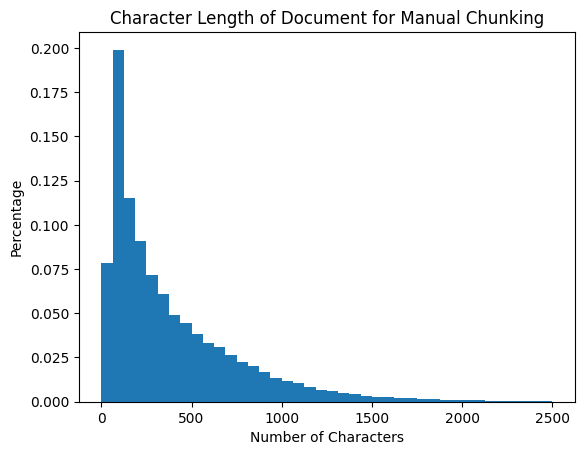

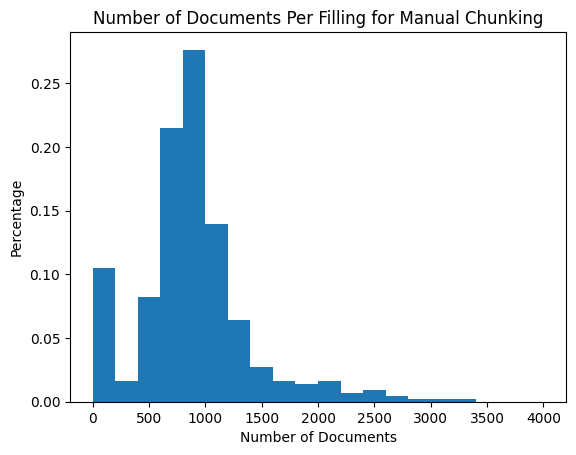

max length of all documents 539381
min length of all documents 51
Percentage of documents with over 1000 words 0.08927299914554258
Percentage of documents with over 1500 words 0.03328569394149001
Percentage of documents with over 2000 words 0.019133742930382065
max number of document 4604
min number of document 2
Percentage of ticker with less than 25 documents 0.00684931506849315
Percentage of ticker with less than 50 documents 0.0365296803652968
Percentage of ticker with less than 100 documents 0.0867579908675799


In [64]:
# Run analysis on document split by paragraph
db = Chroma(collection_name="k-10s", embedding_function=OllamaEmbeddings(model="all-minilm"), persist_directory="../chroma_langchain_db")
chromadb_analysis(db, title = 'Manual Chunking')

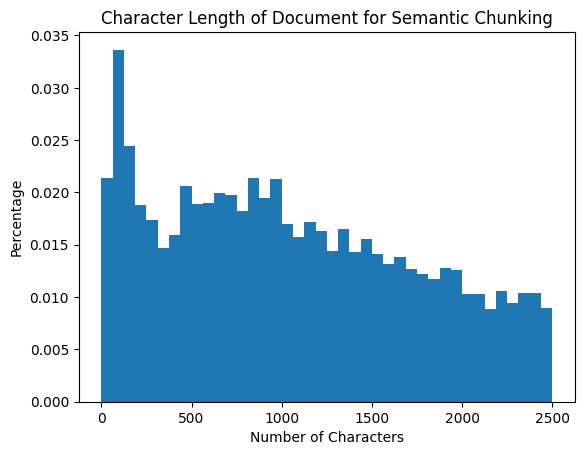

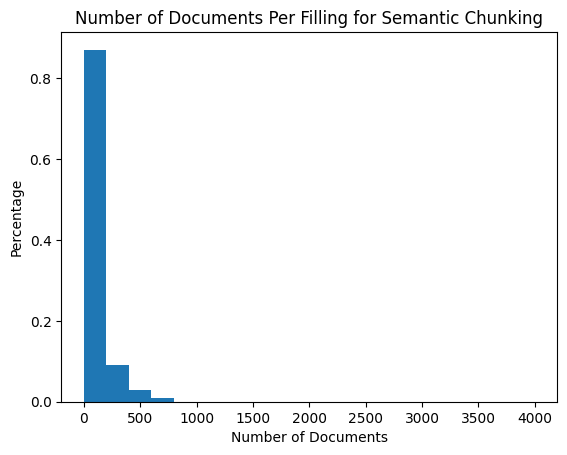

max length of all documents 133065
min length of all documents 0
Percentage of documents with over 1000 words 0.6750583771161704
Percentage of documents with over 1500 words 0.5480151780502043
Percentage of documents with over 2000 words 0.44490659661412724
max number of document 664
min number of document 1
Percentage of ticker with less than 25 documents 0.11
Percentage of ticker with less than 50 documents 0.13
Percentage of ticker with less than 100 documents 0.25


In [65]:
# Run analysis on document split by paragraph
db = Chroma(collection_name="k-10s", embedding_function=OllamaEmbeddings(model="all-minilm"), persist_directory="../chroma_langchain_db_semantic")
chromadb_analysis(db, title = 'Semantic Chunking')